In [83]:
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PowerTransformer

# models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

# metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    explained_variance_score,
    max_error,
    median_absolute_error,
    mean_squared_log_error
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os, random, numpy as np, tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

In [84]:
df = pd.read_csv("Input data for winter wheat yield forecasting.csv")

print("Shape of dataset:", df.shape)

df.head()

Shape of dataset: (1462, 90)


,ID,NDVI_month_10,NDVI_month_11,NDVI_month_12,NDVI_month_01,NDVI_month_02,NDVI_month_03,NDVI_month_04,NDVI_month_05,EVI_month_10,...,SRAD_Month_05,VPD_Month_10,VPD_Month_11,VPD_Month_12,VPD_Month_01,VPD_Month_02,VPD_Month_03,VPD_Month_04,VPD_Month_05,yield
0,320100.0,0.339859,0.275594,0.351865,0.338404,0.404863,0.568072,0.662830,0.542381,0.199389,...,230.394444,0.909444,0.529444,0.285556,0.303889,0.222222,0.482778,0.955556,1.034444,4641.0
1,320111.0,0.368564,0.355827,0.383527,0.384700,0.403745,0.547573,0.620145,0.581745,0.200827,...,231.618750,0.934063,0.525312,0.274688,0.300000,0.231563,0.529062,0.961562,1.054062,3357.0
2,320115.0,0.353104,0.289041,0.342615,0.335356,0.362989,0.546133,0.613963,0.487318,0.195674,...,227.525490,0.920196,0.519020,0.273529,0.288627,0.218235,0.498039,0.940392,1.017451,3930.0
3,320116.0,0.353892,0.352799,0.400063,0.397209,0.419189,0.548955,0.666771,0.568607,0.194413,...,233.008696,0.904493,0.511739,0.267681,0.301594,0.227681,0.507391,0.970580,1.061449,3897.0
4,320117.0,0.381522,0.362056,0.409033,0.400467,0.394089,0.581844,0.633911,0.475900,0.210300,...,223.138636,0.902273,0.500455,0.260000,0.277727,0.204773,0.477727,0.904545,0.970909,4050.0


In [85]:
print("Dataset Info")
print("---------------------")

df.info()

print("\nStatistical Summary")
print("---------------------")

df.describe()

Dataset Info
---------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 90 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              1385 non-null   float64
 1   NDVI_month_10   1385 non-null   float64
 2   NDVI_month_11   1385 non-null   float64
 3   NDVI_month_12   1385 non-null   float64
 4   NDVI_month_01   1385 non-null   float64
 5   NDVI_month_02   1385 non-null   float64
 6   NDVI_month_03   1385 non-null   float64
 7   NDVI_month_04   1385 non-null   float64
 8   NDVI_month_05   1385 non-null   float64
 9   EVI_month_10    1385 non-null   float64
 10  EVI_month_11    1385 non-null   float64
 11  EVI_month_12    1385 non-null   float64
 12  EVI_month_01    1385 non-null   float64
 13  EVI_month_02    1385 non-null   float64
 14  EVI_month_03    1385 non-null   float64
 15  EVI_month_04    1385 non-null   float64
 16  EVI_month_05    1385 non-null   float64
 17

,ID,NDVI_month_10,NDVI_month_11,NDVI_month_12,NDVI_month_01,NDVI_month_02,NDVI_month_03,NDVI_month_04,NDVI_month_05,EVI_month_10,...,SRAD_Month_05,VPD_Month_10,VPD_Month_11,VPD_Month_12,VPD_Month_01,VPD_Month_02,VPD_Month_03,VPD_Month_04,VPD_Month_05,yield
count,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,...,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000,1385.000000
mean,320735.289531,0.455393,0.369415,0.363979,0.364412,0.429340,0.578172,0.673433,0.586624,0.275943,...,229.540982,0.708334,0.456294,0.319705,0.274161,0.301834,0.490294,0.717089,0.988457,5305.378339
std,359.130800,0.071719,0.064614,0.074010,0.075348,0.081319,0.070488,0.071833,0.094775,0.052429,...,20.059680,0.136733,0.109729,0.059519,0.054852,0.085023,0.104985,0.145760,0.209606,639.538990
min,320100.000000,0.222460,0.211854,0.188974,0.174798,0.220680,0.331800,0.432300,0.377353,0.114339,...,178.738525,0.313681,0.163913,0.209481,0.179328,0.150417,0.290659,0.379294,0.446269,3111.000000
25%,320481.000000,0.406620,0.325243,0.311187,0.307839,0.370930,0.532658,0.618695,0.509354,0.241490,...,216.220290,0.637185,0.365926,0.272655,0.230211,0.226032,0.410360,0.607127,0.837653,4838.000000
50%,320723.000000,0.464261,0.363019,0.350454,0.354374,0.423678,0.584181,0.680826,0.581641,0.276686,...,232.215190,0.699369,0.483824,0.306437,0.264737,0.301493,0.471154,0.711739,0.969010,5454.000000
75%,321003.000000,0.505086,0.407156,0.406208,0.412380,0.482891,0.628716,0.731928,0.665891,0.310789,...,243.355000,0.780556,0.522794,0.362549,0.308519,0.364631,0.558837,0.814747,1.132069,5826.000000
max,321324.000000,0.659078,0.600217,0.607751,0.616609,0.669579,0.779300,0.814942,0.822823,0.457962,...,271.829703,1.151935,0.731158,0.500000,0.407582,0.559189,0.837333,1.227857,1.731776,6889.000000


In [86]:
print("All Columns in Dataset")
print("-----------------------")

for col in df.columns:
    print(col)

All Columns in Dataset
-----------------------
ID
NDVI_month_10
NDVI_month_11
NDVI_month_12
NDVI_month_01
NDVI_month_02
NDVI_month_03
NDVI_month_04
NDVI_month_05
EVI_month_10
EVI_month_11
EVI_month_12
EVI_month_01
EVI_month_02
EVI_month_03
EVI_month_04
EVI_month_05
NIRv_month_10
NIRv_month_11
NIRv_month_12
NIRv_month_01
NIRv_month_02
NIRv_month_03
NIRv_month_04
NIRv_month_05
CSIF_month_10
CSIF_month_11
CSIF_month_12
CSIF_month_01
CSIF_month_02
CSIF_month_03
CSIF_month_04
CSIF_month_05
GOSIF_month_10
GOSIF_month_11
GOSIF_month_12
GOSIF_month_01
GOSIF_month_02
GOSIF_month_03
GOSIF_month_04
GOSIF_month_05
SM_month_10
SM_month_11
SM_month_12
SM_month_01
SM_month_02
SM_month_03
SM_month_04
SM_month_05
Prec_month_10
Prec_month_11
Prec_month_12
Prec_month_01
Prec_month_02
Prec_month_03
Prec_month_04
Prec_month_05
Tmax_month_10
Tmax_month_11
Tmax_month_12
Tmax_month_01
Tmax_month_02
Tmax_month_03
Tmax_month_04
Tmax_month_05
Tmin_month_10
Tmin_month_11
Tmin_month_12
Tmin_month_01
Tmin_month_02


In [87]:
# remove ID column if present
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# remove rows where yield is missing
df = df.dropna(subset=["yield"])

# separate features and target
X = df.drop(columns=["yield"])
y = df["yield"]

# fill remaining missing values
X = X.fillna(X.mean())

print("Final Feature Shape:", X.shape)

Final Feature Shape: (1385, 88)


In [88]:
# Train test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1108, 88)
Testing shape: (277, 88)


In [89]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


In [90]:
def evaluate_model(y_true, y_pred, n_features):

    r2 = r2_score(y_true, y_pred)

    adj_r2 = 1 - (1 - r2) * ((len(y_true) - 1) / (len(y_true) - n_features - 1))

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(y_true, y_pred)

    mape = mean_absolute_percentage_error(y_true, y_pred)

    explained_var = explained_variance_score(y_true, y_pred)

    max_err = max_error(y_true, y_pred)

    median_ae = median_absolute_error(y_true, y_pred)

    try:
        rmsle = np.sqrt(mean_squared_log_error(y_true, np.maximum(0, y_pred)))
    except:
        rmsle = np.nan

    return {
        "R2": r2,
        "Adjusted R2": adj_r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "RMSLE": rmsle,
        "Explained Variance": explained_var,
        "Max Error": max_err,
        "Median AE": median_ae
    }

In [91]:
models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(),

    "ElasticNet": ElasticNet(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42),

    "AdaBoost": AdaBoostRegressor(random_state=42),

    "SVR": SVR(),

    "KNN": KNeighborsRegressor()
}

In [92]:
baseline_results = []

for name, model in models.items():

    if name in ["SVR", "KNN", "ElasticNet"]:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    metrics = evaluate_model(y_test, predictions, X_train.shape[1])

    metrics["Model"] = name

    baseline_results.append(metrics)

baseline_df = pd.DataFrame(baseline_results)

baseline_df = baseline_df.set_index("Model")

baseline_df

,R2,Adjusted R2,MSE,RMSE,MAE,MAPE,RMSLE,Explained Variance,Max Error,Median AE
Model,,,,,,,,,,
Linear Regression,0.722016,0.591896,107129.463660,327.306376,249.628151,0.048673,0.066155,0.722019,1453.039591,197.487417
Ridge Regression,0.694605,0.551653,117693.240236,343.064484,267.036565,0.052083,0.068958,0.694775,1452.822003,221.835231
Lasso Regression,0.686642,0.539963,120761.933566,347.508178,273.194505,0.053390,0.069986,0.686777,1399.853228,226.259049
ElasticNet,0.655999,0.494978,132570.948170,364.102936,286.302164,0.056057,0.073491,0.656421,1344.687192,252.429181
Decision Tree,0.455883,0.201190,209691.671480,457.921032,314.920578,0.061474,0.093658,0.464843,1700.000000,196.000000
Random Forest,0.767622,0.658850,89553.605443,299.255084,214.603141,0.042406,0.061347,0.770218,1108.880000,148.740000
Gradient Boosting,0.765818,0.656200,90249.129725,300.414929,218.026061,0.042930,0.061046,0.766339,1178.755943,145.564642
AdaBoost,0.632348,0.460256,141685.635204,376.411524,293.231921,0.056804,0.075523,0.649539,1244.701031,245.678322
SVR,0.101022,-0.319776,346448.012027,588.598345,477.862204,0.097182,0.119551,0.118425,2179.891072,421.268151


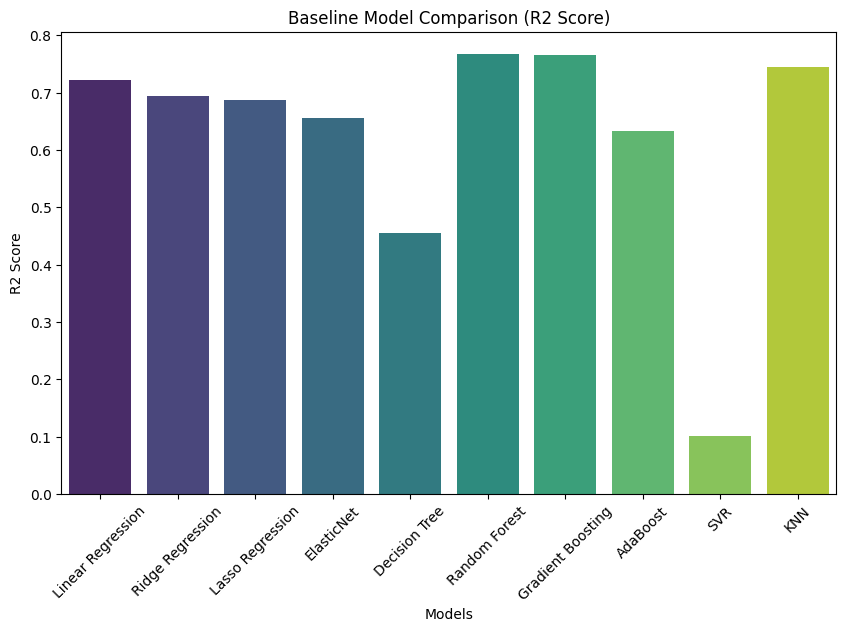

In [93]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=baseline_df.index,
    y=baseline_df["R2"],
    palette="viridis"
)

plt.xticks(rotation=45)
plt.title("Baseline Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xlabel("Models")

plt.show()

In [94]:
baseline_df.sort_values("R2", ascending=False)

,R2,Adjusted R2,MSE,RMSE,MAE,MAPE,RMSLE,Explained Variance,Max Error,Median AE
Model,,,,,,,,,,
Random Forest,0.767622,0.658850,89553.605443,299.255084,214.603141,0.042406,0.061347,0.770218,1108.880000,148.740000
Gradient Boosting,0.765818,0.656200,90249.129725,300.414929,218.026061,0.042930,0.061046,0.766339,1178.755943,145.564642
KNN,0.745040,0.625697,98256.395668,313.458762,226.440433,0.044377,0.063491,0.748768,1230.400000,159.400000
Linear Regression,0.722016,0.591896,107129.463660,327.306376,249.628151,0.048673,0.066155,0.722019,1453.039591,197.487417
Ridge Regression,0.694605,0.551653,117693.240236,343.064484,267.036565,0.052083,0.068958,0.694775,1452.822003,221.835231
Lasso Regression,0.686642,0.539963,120761.933566,347.508178,273.194505,0.053390,0.069986,0.686777,1399.853228,226.259049
ElasticNet,0.655999,0.494978,132570.948170,364.102936,286.302164,0.056057,0.073491,0.656421,1344.687192,252.429181
AdaBoost,0.632348,0.460256,141685.635204,376.411524,293.231921,0.056804,0.075523,0.649539,1244.701031,245.678322
Decision Tree,0.455883,0.201190,209691.671480,457.921032,314.920578,0.061474,0.093658,0.464843,1700.000000,196.000000


In [95]:
best_model_name = baseline_df["R2"].idxmax()

print("Best Baseline Model:", best_model_name)

Best Baseline Model: Random Forest


In [96]:
best_model = models[best_model_name]

if best_model_name in ["SVR", "KNN", "ElasticNet"]:
    best_model.fit(X_train_scaled, y_train)
    preds = best_model.predict(X_test_scaled)
else:
    best_model.fit(X_train, y_train)
    preds = best_model.predict(X_test)

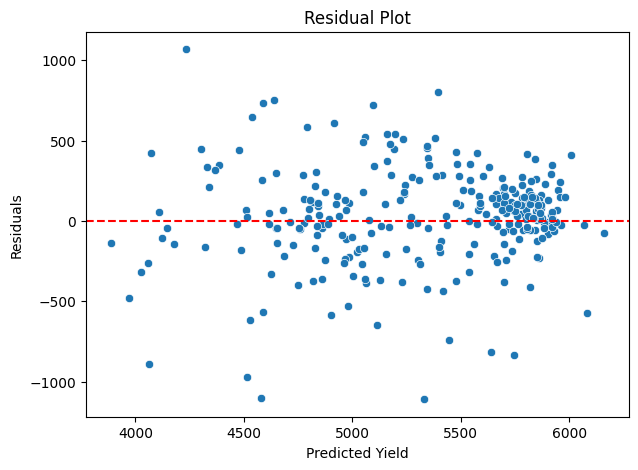

In [97]:
residuals = y_test - preds

plt.figure(figsize=(7,5))

sns.scatterplot(x=preds, y=residuals)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [98]:
!pip install catboost

In [99]:
# 🚀 Step 1: Train Advanced Models (XGBoost, LightGBM, CatBoost)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Initialize models
xgb_model = XGBRegressor(random_state=42)
lgb_model = LGBMRegressor(random_state=42)
cat_model = CatBoostRegressor(verbose=0, random_state=42)

# Store models
advanced_models = {
    "XGBoost": xgb_model,
    "LightGBM": lgb_model,
    "CatBoost": cat_model
}

# Store results
advanced_results = {}

print("===== Advanced Model Results =====")

# Train and evaluate each model
for name, model in advanced_models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    predictions = model.predict(X_test)

    # Evaluate
    r2 = r2_score(y_test, predictions)

    # Store
    advanced_results[name] = r2

    print(f"{name} R2 Score: {r2:.4f}")

print("\nAll Advanced Results:", advanced_results)

===== Advanced Model Results =====
XGBoost R2 Score: 0.7739
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002525 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22440
[LightGBM] [Info] Number of data points in the train set: 1108, number of used features: 88
[LightGBM] [Info] Start training from score 5294.123646
LightGBM R2 Score: 0.7898
CatBoost R2 Score: 0.7950

All Advanced Results: {'XGBoost': 0.7739257226102421, 'LightGBM': 0.7897903544031202, 'CatBoost': 0.7949857499155406}


In [100]:
# 🏆 Step 2: Select Best Advanced Model

# Find best model based on R2 score
best_model_name = max(advanced_results, key=advanced_results.get)

print("Best Advanced Model is:", best_model_name)

# Get corresponding model object
best_model = advanced_models[best_model_name]

print("Selected Model Object:", best_model)

Best Advanced Model is: CatBoost
Selected Model Object: CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0)


In [101]:
# 🔧 Step 3: Hyperparameter Tuning of BEST model

from sklearn.model_selection import RandomizedSearchCV

# Tuning based on which model won

if best_model_name == "XGBoost":

    print("\nTuning XGBoost...\n")

    param_dist = {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [3, 6, 10],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0]
    }

    tuner = RandomizedSearchCV(
        estimator=XGBRegressor(random_state=42),
        param_distributions=param_dist,
        n_iter=10,
        scoring="r2",
        cv=3,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    tuner.fit(X_train, y_train)

    best_model = tuner.best_estimator_

    print("Best Parameters for XGBoost:", tuner.best_params_)


elif best_model_name == "LightGBM":

    print("\nTuning LightGBM...\n")

    param_dist = {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1],
        "num_leaves": [31, 50, 100],
        "max_depth": [-1, 10, 20]
    }

    tuner = RandomizedSearchCV(
        estimator=LGBMRegressor(random_state=42),
        param_distributions=param_dist,
        n_iter=10,
        scoring="r2",
        cv=3,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    tuner.fit(X_train, y_train)

    best_model = tuner.best_estimator_

    print("Best Parameters for LightGBM:", tuner.best_params_)


elif best_model_name == "CatBoost":

    print("\nTuning CatBoost...\n")

    param_dist = {
        "depth": [4, 6, 10],
        "learning_rate": [0.01, 0.05, 0.1],
        "iterations": [100, 200, 300]
    }

    tuner = RandomizedSearchCV(
        estimator=CatBoostRegressor(verbose=0, random_state=42),
        param_distributions=param_dist,
        n_iter=10,
        scoring="r2",
        cv=3,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    tuner.fit(X_train, y_train)

    best_model = tuner.best_estimator_

    print("Best Parameters for CatBoost:", tuner.best_params_)


else:
    print("No tuning applied")


Tuning CatBoost...

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters for CatBoost: {'learning_rate': 0.1, 'iterations': 300, 'depth': 6}


In [102]:
# 📊 Step 4: Evaluate Tuned Model

tuned_predictions = best_model.predict(X_test)

r2 = r2_score(y_test, tuned_predictions)
rmse = np.sqrt(mean_squared_error(y_test, tuned_predictions))
mae = mean_absolute_error(y_test, tuned_predictions)

print("\n===== Tuned Model Performance =====")
print("R2 Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)


===== Tuned Model Performance =====
R2 Score: 0.780472479455312
RMSE: 290.86331867947075
MAE: 209.140315537679


In [103]:
# 📊 Feature Importance using BEST MODEL (Correct)

# Fit best model again (safe step)
best_model.fit(X_train, y_train)

# Get feature importances
importances = best_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,   # use original column names
    "Importance": importances
})

# Sort
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top features
feature_importance_df.head(20)

,Feature,Importance
14,EVI_month_04,7.246227
38,GOSIF_month_04,6.111083
22,NIRv_month_04,3.881763
57,Tmax_month_11,3.064293
53,Prec_month_03,2.741869
56,Tmax_month_10,2.705633
48,Prec_month_10,2.559954
39,GOSIF_month_05,2.317708
65,Tmin_month_11,2.113425
76,SRAD_Month_02,1.934675


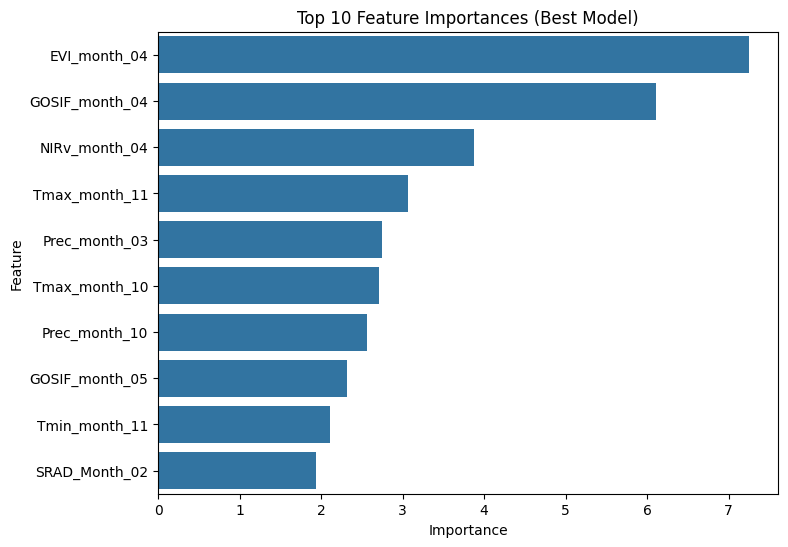

In [104]:
plt.figure(figsize=(8,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df.head(10)
)
plt.title("Top 10 Feature Importances (Best Model)")
plt.show()

In [105]:
!pip install sklearn-genetic-opt

In [106]:
# 🧬 GA Feature Selection using BEST MODEL (FIXED)

from sklearn_genetic import GAFeatureSelectionCV
from sklearn.base import clone

print("Starting GA Feature Selection...")

ga_selector = GAFeatureSelectionCV(
    estimator=clone(best_model),   # ✅ VERY IMPORTANT
    cv=3,
    scoring="r2",
    population_size=12,            # safe config
    generations=6,
    n_jobs=-1,
    verbose=True,
    keep_top_k=2
)

ga_selector.fit(X_train, y_train)

print("GA Feature Selection Completed")

Starting GA Feature Selection...
gen	nevals	fitness	fitness_std	fitness_max	fitness_min
0  	12    	0.72809	0.00759682 	0.739998   	0.710303   
1  	24    	0.733472	0.00653107 	0.739998   	0.720621   
2  	24    	0.737445	0.00273721 	0.742833   	0.732877   
3  	24    	0.738247	0.00333191 	0.742833   	0.731888   
4  	24    	0.735031	0.00644473 	0.742833   	0.719834   
5  	24    	0.73379 	0.0071477  	0.742833   	0.719834   
6  	24    	0.73368 	0.0062149  	0.742833   	0.720954   
GA Feature Selection Completed


In [107]:
# 📊 Get selected features

selected_features = ga_selector.support_

print("Selected Features Mask:")
print(selected_features)

Selected Features Mask:
[ True  True  True False  True  True False False False  True False False
  True False  True False False  True False False  True  True  True False
  True  True  True  True  True  True  True  True  True  True False  True
  True False  True False  True False  True False  True  True  True  True
  True False  True  True False False False  True  True False  True  True
 False False  True False  True False False False False False  True  True
  True False False False  True  True  True  True  True False False False
  True False False  True]


In [108]:
# 🔄 Transform dataset using selected features

X_train_selected = ga_selector.transform(X_train)
X_test_selected = ga_selector.transform(X_test)

print("New shape after GA:", X_train_selected.shape)

New shape after GA: (1108, 50)


In [109]:
# 🔁 Retrain best model on selected features

from sklearn.base import clone

final_model = clone(best_model)

final_model.fit(X_train_selected, y_train)

final_preds = final_model.predict(X_test_selected)

r2_ga = r2_score(y_test, final_preds)
rmse_ga = np.sqrt(mean_squared_error(y_test, final_preds))

print("R2 after GA:", r2_ga)
print("RMSE after GA:", rmse_ga)

R2 after GA: 0.7820196972956354
RMSE after GA: 289.8365119582473


In [110]:
# 📊 Selected features from GA

selected_features_ga = ga_selector.support_

selected_feature_names = X_train.columns[selected_features_ga]

print("Selected Features (GA):")
print(selected_feature_names)

Selected Features (GA):
Index(['NDVI_month_10', 'NDVI_month_11', 'NDVI_month_12', 'NDVI_month_02',
       'NDVI_month_03', 'EVI_month_11', 'EVI_month_02', 'EVI_month_04',
       'NIRv_month_11', 'NIRv_month_02', 'NIRv_month_03', 'NIRv_month_04',
       'CSIF_month_10', 'CSIF_month_11', 'CSIF_month_12', 'CSIF_month_01',
       'CSIF_month_02', 'CSIF_month_03', 'CSIF_month_04', 'CSIF_month_05',
       'GOSIF_month_10', 'GOSIF_month_11', 'GOSIF_month_01', 'GOSIF_month_02',
       'GOSIF_month_04', 'SM_month_10', 'SM_month_12', 'SM_month_02',
       'SM_month_03', 'SM_month_04', 'SM_month_05', 'Prec_month_10',
       'Prec_month_12', 'Prec_month_01', 'Prec_month_05', 'Tmax_month_10',
       'Tmax_month_12', 'Tmax_month_01', 'Tmax_month_04', 'Tmin_month_10',
       'Tmin_month_04', 'Tmin_month_05', 'SRAD_Month_10', 'SRAD_Month_02',
       'SRAD_Month_03', 'SRAD_Month_04', 'SRAD_Month_05', 'VPD_Month_10',
       'VPD_Month_02', 'VPD_Month_05'],
      dtype='object')


In [111]:
!pip install pyswarms

In [112]:
# 🐝 PSO Imports (FIXED)

import pyswarms as ps
import numpy as np

from sklearn.model_selection import cross_val_score
from sklearn.base import clone

print("PSO setup ready")

PSO setup ready


In [113]:
# 🧠 PSO Fitness Function (FIXED)

def fitness_function(particles):

    n_particles = particles.shape[0]
    scores = []

    for i in range(n_particles):

        # Convert continuous → binary
        particle = particles[i]
        selected = particle > 0.5

        # If no feature selected → penalize
        if np.sum(selected) == 0:
            scores.append(1)
            continue

        # ✅ FIX: use NumPy array
        X_subset = X_train.values[:, selected]

        # Use best model
        model = clone(best_model)

        # Cross-validation
        score = cross_val_score(
            model,
            X_subset,
            y_train,
            cv=3,
            scoring="r2"
        ).mean()

        # PSO minimizes → negative
        scores.append(-score)

    return np.array(scores)

In [114]:
# 🚀 Run PSO Feature Selection

X_train_np = X_train.values   # ✅ IMPORTANT

n_features = X_train.shape[1]

options = {
    'c1': 0.5,
    'c2': 0.3,
    'w': 0.9
}

optimizer = ps.single.GlobalBestPSO(
    n_particles=10,
    dimensions=n_features,
    options=options
)

print("Starting PSO...")

best_cost, best_pos = optimizer.optimize(
    fitness_function,
    iters=10
)

print("PSO Completed")

2026-03-24 19:13:02,378 - pyswarms.single.global_best - INFO - Optimize for 10 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


Starting PSO...


pyswarms.single.global_best: 100%|██████████|10/10, best_cost=-0.743
2026-03-24 19:47:48,199 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.7432563253914622, best pos: [1.67213495 1.81312013 2.02147623 1.71001343 1.08184215 1.31454493
 2.27889453 0.84589623 2.06600555 2.0167151  1.3667989  1.89642425
 1.28471325 2.80320812 1.22205948 2.75738106 1.24966397 2.079796
 0.63589604 1.90800337 2.49349923 1.17387907 1.48497256 2.43996588
 0.49972264 1.91258255 1.66108763 1.23148705 0.8855127  1.41924888
 1.61901133 1.44963616 1.85014483 1.68083041 1.95480529 0.30430759
 0.62374136 1.69620506 1.49789002 1.44002475 1.29137416 1.0090494
 2.54545525 2.32339886 1.10002448 1.53072888 0.93115944 0.92613747
 0.78081857 1.76878284 1.50093457 1.77407967 1.26256594 1.86701363
 1.54345699 1.2976452  2.77118748 1.34655613 1.79746133 2.18497094
 2.42771802 1.84847401 1.84020596 0.8578411  1.93179611 1.57054453
 2.01748886 0.35788254 2.13581093 0.9994036  1.95045589 1.19643728
 

PSO Completed


In [115]:
# 📊 Extract selected features

selected_features_pso = best_pos > 0.5

print("Selected Features (PSO):")
print(selected_features_pso)

Selected Features (PSO):
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
 False  True  True  True  True  True  True  True  True  True  True False
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True False  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True False  True  True]


In [116]:
# 🔄 Transform dataset (FIXED)

X_train_pso = X_train.values[:, selected_features_pso]
X_test_pso = X_test.values[:, selected_features_pso]

print("New shape after PSO:", X_train_pso.shape)

New shape after PSO: (1108, 84)


In [117]:
# 🔁 Retrain using PSO features

final_model_pso = clone(best_model)

final_model_pso.fit(X_train_pso, y_train)

preds_pso = final_model_pso.predict(X_test_pso)

r2_pso = r2_score(y_test, preds_pso)
rmse_pso = np.sqrt(mean_squared_error(y_test, preds_pso))

print("R2 after PSO:", r2_pso)
print("RMSE after PSO:", rmse_pso)

R2 after PSO: 0.7957341298541664
RMSE after PSO: 280.5707370710666


In [118]:
# 📊 Selected features from PSO

selected_feature_names_pso = X_train.columns[selected_features_pso]

print("Selected Features (PSO):")
print(selected_feature_names_pso)

Selected Features (PSO):
Index(['NDVI_month_10', 'NDVI_month_11', 'NDVI_month_12', 'NDVI_month_01',
       'NDVI_month_02', 'NDVI_month_03', 'NDVI_month_04', 'NDVI_month_05',
       'EVI_month_10', 'EVI_month_11', 'EVI_month_12', 'EVI_month_01',
       'EVI_month_02', 'EVI_month_03', 'EVI_month_04', 'EVI_month_05',
       'NIRv_month_10', 'NIRv_month_11', 'NIRv_month_12', 'NIRv_month_01',
       'NIRv_month_02', 'NIRv_month_03', 'NIRv_month_04', 'NIRv_month_05',
       'CSIF_month_11', 'CSIF_month_12', 'CSIF_month_01', 'CSIF_month_02',
       'CSIF_month_03', 'CSIF_month_04', 'CSIF_month_05', 'GOSIF_month_10',
       'GOSIF_month_11', 'GOSIF_month_12', 'GOSIF_month_02', 'GOSIF_month_03',
       'GOSIF_month_04', 'GOSIF_month_05', 'SM_month_10', 'SM_month_11',
       'SM_month_12', 'SM_month_01', 'SM_month_02', 'SM_month_03',
       'SM_month_04', 'SM_month_05', 'Prec_month_10', 'Prec_month_11',
       'Prec_month_12', 'Prec_month_01', 'Prec_month_02', 'Prec_month_03',
       'Prec_mont

In [119]:
!pip install scikit-opt

In [120]:
# 🎵 Harmony Search Feature Selection

import numpy as np
from sklearn.base import clone

print("Starting Harmony Search...")

Starting Harmony Search...


In [121]:
def evaluate_harmony(solution):

    selected = solution == 1

    if np.sum(selected) == 0:
        return 0

    X_subset = X_train.values[:, selected]

    model = clone(best_model)

    score = cross_val_score(
        model,
        X_subset,
        y_train,
        cv=3,
        scoring="r2"
    ).mean()

    return score

In [122]:
# 🎯 Parameters

n_features = X_train.shape[1]
harmony_memory_size = 10
iterations = 20   # ~10–20 min
hmcr = 0.9        # Harmony Memory Consideration Rate
par = 0.3         # Pitch Adjustment Rate

In [123]:
# 🎼 Initialize harmony memory

harmony_memory = []
fitness_scores = []

for _ in range(harmony_memory_size):
    solution = np.random.randint(0, 2, n_features)
    score = evaluate_harmony(solution)

    harmony_memory.append(solution)
    fitness_scores.append(score)

In [124]:
# 🚀 Harmony Search Optimization

for i in range(iterations):

    new_solution = np.zeros(n_features)

    for j in range(n_features):

        if np.random.rand() < hmcr:
            # pick from memory
            idx = np.random.randint(harmony_memory_size)
            new_solution[j] = harmony_memory[idx][j]

            # pitch adjustment
            if np.random.rand() < par:
                new_solution[j] = 1 - new_solution[j]
        else:
            new_solution[j] = np.random.randint(0, 2)

    new_solution = new_solution.astype(int)
    new_score = evaluate_harmony(new_solution)

    # replace worst
    worst_idx = np.argmin(fitness_scores)

    if new_score > fitness_scores[worst_idx]:
        harmony_memory[worst_idx] = new_solution
        fitness_scores[worst_idx] = new_score

    print(f"Iteration {i+1}, Best Score: {max(fitness_scores)}")

print("Harmony Search Completed")

Iteration 1, Best Score: 0.735332694921572
Iteration 2, Best Score: 0.735332694921572
Iteration 3, Best Score: 0.735332694921572
Iteration 4, Best Score: 0.735332694921572
Iteration 5, Best Score: 0.7382533339201042
Iteration 6, Best Score: 0.7382533339201042
Iteration 7, Best Score: 0.7382533339201042
Iteration 8, Best Score: 0.7382533339201042
Iteration 9, Best Score: 0.7382533339201042
Iteration 10, Best Score: 0.7382533339201042
Iteration 11, Best Score: 0.7382533339201042
Iteration 12, Best Score: 0.7382533339201042
Iteration 13, Best Score: 0.7382533339201042
Iteration 14, Best Score: 0.7382533339201042
Iteration 15, Best Score: 0.7382533339201042
Iteration 16, Best Score: 0.7382533339201042
Iteration 17, Best Score: 0.7388360722393035
Iteration 18, Best Score: 0.7388360722393035
Iteration 19, Best Score: 0.7388360722393035
Iteration 20, Best Score: 0.7388360722393035
Harmony Search Completed


In [125]:
# 📊 Best solution

best_idx = np.argmax(fitness_scores)
best_solution_hs = harmony_memory[best_idx]

selected_features_hs = best_solution_hs == 1

In [126]:
# 🔄 Transform

X_train_hs = X_train.values[:, selected_features_hs]
X_test_hs = X_test.values[:, selected_features_hs]

# 🔁 Retrain

final_model_hs = clone(best_model)

final_model_hs.fit(X_train_hs, y_train)

preds_hs = final_model_hs.predict(X_test_hs)

r2_hs = r2_score(y_test, preds_hs)
rmse_hs = np.sqrt(mean_squared_error(y_test, preds_hs))

print("R2 after HS:", r2_hs)
print("RMSE after HS:", rmse_hs)

R2 after HS: 0.7831289890351999
RMSE after HS: 289.0980889672709


In [127]:
# 📊 Selected features from HS

selected_feature_names_hs = X_train.columns[selected_features_hs]

print("Selected Features (HS):")
print(selected_feature_names_hs)

Selected Features (HS):
Index(['NDVI_month_11', 'NDVI_month_12', 'NDVI_month_01', 'NDVI_month_03',
       'NDVI_month_04', 'NDVI_month_05', 'EVI_month_11', 'EVI_month_01',
       'EVI_month_03', 'EVI_month_04', 'NIRv_month_11', 'NIRv_month_01',
       'NIRv_month_03', 'NIRv_month_04', 'CSIF_month_10', 'CSIF_month_11',
       'CSIF_month_02', 'CSIF_month_05', 'GOSIF_month_10', 'GOSIF_month_11',
       'GOSIF_month_02', 'GOSIF_month_03', 'GOSIF_month_04', 'SM_month_11',
       'SM_month_01', 'SM_month_02', 'SM_month_04', 'SM_month_05',
       'Prec_month_10', 'Prec_month_12', 'Prec_month_02', 'Prec_month_03',
       'Prec_month_04', 'Prec_month_05', 'Tmax_month_11', 'Tmax_month_01',
       'Tmax_month_02', 'Tmax_month_05', 'Tmin_month_12', 'Tmin_month_01',
       'Tmin_month_03', 'Tmin_month_05', 'SRAD_Month_10', 'SRAD_Month_11',
       'SRAD_Month_12', 'SRAD_Month_01', 'SRAD_Month_02', 'VPD_Month_10',
       'VPD_Month_12', 'VPD_Month_01', 'VPD_Month_03', 'VPD_Month_05'],
      dtype='o

In [128]:
print("GA selected:", len(selected_feature_names))
print("PSO selected:", len(selected_feature_names_pso))
print("HS selected:", len(selected_feature_names_hs))

GA selected: 50
PSO selected: 84
HS selected: 52


In [129]:
# 📊 Dynamic Comparison Table

comparison = pd.DataFrame({
    "Method": ["GA", "PSO", "HS"],
    "R2 Score": [r2_ga, r2_pso, r2_hs],
    "RMSE": [rmse_ga, rmse_pso, rmse_hs]
})

comparison

,Method,R2 Score,RMSE
0,GA,0.782020,289.836512
1,PSO,0.795734,280.570737
2,HS,0.783129,289.098089


In [130]:
# 🏆 Automatically select best method

best_method = comparison.loc[comparison["R2 Score"].idxmax(), "Method"]

print("Best Optimization Method:", best_method)

Best Optimization Method: PSO


In [131]:
# 🔁 Assign final dataset based on best method

if best_method == "GA":
    X_train_final = X_train_selected
    X_test_final = X_test_selected

elif best_method == "PSO":
    X_train_final = X_train_pso
    X_test_final = X_test_pso

elif best_method == "HS":
    X_train_final = X_train_hs
    X_test_final = X_test_hs
print("Using method:", best_method)
print("Final shape:", X_train_final.shape)

Using method: PSO
Final shape: (1108, 84)


In [132]:
from sklearn.preprocessing import StandardScaler

# Scale X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_final)
X_test_scaled = scaler_X.transform(X_test_final)

# Scale y (VERY IMPORTANT)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))

In [133]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

mlp_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

mlp_model.compile(optimizer='adam', loss='mse')

In [134]:
mlp_model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.6552 - val_loss: 0.4301
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3473 - val_loss: 0.3213
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2723 - val_loss: 0.2770
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2278 - val_loss: 0.2604
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2008 - val_loss: 0.2407
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1804 - val_loss: 0.2384
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1664 - val_loss: 0.2207
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1541 - val_loss: 0.2344
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1461 - val_loss: 0.2236
Epoch 10/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1415 - val_loss: 0.2161
Epoch 11/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1314 - val_loss: 0.2218
Epoch 12/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1232 - val_l

In [135]:
mlp_preds_scaled = mlp_model.predict(X_test_scaled)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [136]:
mlp_preds = scaler_y.inverse_transform(mlp_preds_scaled).flatten()

In [137]:
r2_mlp = r2_score(y_test, mlp_preds)
rmse_mlp = np.sqrt(mean_squared_error(y_test, mlp_preds))

print("R2 (MLP):", r2_mlp)
print("RMSE (MLP):", rmse_mlp)

R2 (MLP): 0.7340756721111241
RMSE (MLP): 320.1278839868462


In [138]:
# 📊 Evaluate MLP (FIXED: use scaled input + inverse transform)

mlp_preds_scaled2 = mlp_model.predict(X_test_scaled)
mlp_preds = scaler_y.inverse_transform(mlp_preds_scaled2).flatten()

r2_mlp = r2_score(y_test, mlp_preds)
rmse_mlp = np.sqrt(mean_squared_error(y_test, mlp_preds))

print("R2 (MLP):", r2_mlp)
print("RMSE (MLP):", rmse_mlp)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
R2 (MLP): 0.7340756721111241
RMSE (MLP): 320.1278839868462


In [139]:
!pip install pytorch-tabnet --quiet

In [140]:
# 🔧 Define TabNet Regressor (MISSING CELL – ADDED)

from pytorch_tabnet.tab_model import TabNetRegressor

tabnet_model = TabNetRegressor(
    n_d=16, n_a=16,
    n_steps=3,
    gamma=1.3,
    seed=42,
    verbose=0
)
print("TabNet model defined")

TabNet model defined


In [141]:
# 🔧 Use SAME scaled data (important consistency)

X_train_tab = X_train_scaled.astype(np.float32)
X_test_tab = X_test_scaled.astype(np.float32)

y_train_tab = y_train_scaled.astype(np.float32)

In [142]:
# 🔧 Use SAME scaled data (important consistency)

X_train_tab = X_train_scaled.astype(np.float32)
X_test_tab = X_test_scaled.astype(np.float32)

y_train_tab = y_train_scaled.astype(np.float32)

In [143]:
tabnet_model.fit(
    X_train_tab,
    y_train_tab,
    eval_set=[(X_train_tab, y_train_tab)],   # ⚠️ use train set for stability
    eval_metric=['rmse'],
    max_epochs=30,
    patience=5,
    batch_size=256,
    virtual_batch_size=64
)

Stop training because you reached max_epochs = 30 with best_epoch = 29 and best_val_0_rmse = 0.51581


In [144]:
tabnet_preds_scaled = tabnet_model.predict(X_test_tab)

In [145]:
tabnet_preds = scaler_y.inverse_transform(tabnet_preds_scaled).flatten()

In [146]:
r2_tabnet = r2_score(y_test, tabnet_preds)
rmse_tabnet = np.sqrt(mean_squared_error(y_test, tabnet_preds))

print("R2 (TabNet):", r2_tabnet)
print("RMSE (TabNet):", rmse_tabnet)

R2 (TabNet): 0.6613155785138054
RMSE (TabNet): 361.2784685321186


In [ ]:
# ==============================
# MAKE TRANSFORMER DETERMINISTIC
# ==============================

import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

In [147]:
# Data stays 2D — FT-Transformer handles the tokenization internally
X_train_tf = X_train_scaled.astype('float32')   # (N, 42)
X_test_tf  = X_test_scaled.astype('float32')
y_train_tf = y_train_scaled.astype('float32').reshape(-1, 1)

print("X_train_tf:", X_train_tf.shape)
print("y_train_tf:", y_train_tf.shape)

X_train_tf: (1108, 84)
y_train_tf: (1108, 1)


In [148]:
import tensorflow as tf
import keras
from keras import layers, models, ops

class FeatureTokenizer(layers.Layer):
    def __init__(self, n_features, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.n_features = n_features
        self.embed_dim  = embed_dim

    def build(self, input_shape):
        self.W = self.add_weight(
            name="token_weights",
            shape=(self.n_features, self.embed_dim),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="token_biases",
            shape=(self.n_features, self.embed_dim),
            initializer="zeros",
            trainable=True
        )

    def call(self, x):
        # x: (batch, n_features)
        # expand to (batch, n_features, 1) then broadcast multiply
        x_expanded = x[:, :, None]                  # None instead of ops.newaxis
        W_expanded = self.W[None, :, :]              # (1, n_features, embed_dim)
        b_expanded = self.b[None, :, :]              # (1, n_features, embed_dim)
        return x_expanded * W_expanded + b_expanded  # (batch, n_features, embed_dim)


class CLSTokenPrepend(layers.Layer):
    def __init__(self, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.cls = self.add_weight(
            name="cls_token",
            shape=(1, 1, self.embed_dim),
            initializer="glorot_uniform",
            trainable=True
        )

    def call(self, x):
        batch_size = ops.shape(x)[0]
        cls_tiled  = ops.broadcast_to(self.cls, (batch_size, 1, self.embed_dim))
        return ops.concatenate([cls_tiled, x], axis=1)


def build_ft_transformer(n_features, embed_dim=32, num_heads=4,
                          ff_dim=128, n_blocks=2, dropout=0.1):

    inputs = layers.Input(shape=(n_features,))

    # 1. Feature tokenization → (N, n_features, embed_dim)
    x = FeatureTokenizer(n_features, embed_dim)(inputs)

    # 2. Prepend CLS token → (N, n_features+1, embed_dim)
    x = CLSTokenPrepend(embed_dim)(x)

    # 3. Transformer encoder blocks
    for _ in range(n_blocks):
        # Self-attention sub-layer
        residual = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout
        )(x, x)
        x = layers.Dropout(dropout)(x)
        x = layers.Add()([residual, x])

        # Feed-forward sub-layer
        residual = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = layers.Dense(ff_dim, activation='gelu')(x)
        x = layers.Dropout(dropout)(x)
        x = layers.Dense(embed_dim)(x)
        x = layers.Dropout(dropout)(x)
        x = layers.Add()([residual, x])

    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # 4. Extract CLS token (index 0)
    cls_out = x[:, 0, :]                     # (N, embed_dim)

    # 5. Regression head
    x = layers.Dense(64, activation='gelu')(cls_out)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(32, activation='gelu')(x)
    outputs = layers.Dense(1)(x)

    return models.Model(inputs, outputs)


n_features = X_train_tf.shape[1]
model = build_ft_transformer(
    n_features=n_features,
    embed_dim=64,
    num_heads=8,
    ff_dim=256,
    n_blocks=4,
    dropout=0.15
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 84)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_tokenizer_1 │ (None, 84, 32)    │      5,376 │ input_layer_3[0]… │
│ (FeatureTokenizer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls_token_prepend_1 │ (None, 85, 32)    │         32 │ feature_tokenize… │
│ (CLSTokenPrepend)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 85, 32)    │         64 │ cls_token_prepen… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 85, 32)    │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 85, 32)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 85, 32)    │          0 │ cls_token_prepen… │
│                     │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 85, 32)    │         64 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 85, 128)   │      4,224 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 85, 128)   │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 85, 32)    │      4,128 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 85, 32)    │          0 │ dense_14[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 85, 32)    │          0 │ add_4[0][0],      │
│                     │                   │            │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 85, 32)    │         64 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 85, 32)    │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 85, 32)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 85, 32)    │          0 │ add_5[0][0],      │
│                     │                   │            │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 35,105 (137.13 KB)

 Trainable params: 35,105 (137.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 27s 414ms/step - loss: 1.1572 - mae: 0.8719 - val_loss: 1.0900 - val_mae: 0.8636
Epoch 2/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 273ms/step - loss: 1.0724 - mae: 0.8574 - val_loss: 0.9447 - val_mae: 0.8088
Epoch 3/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 344ms/step - loss: 0.9578 - mae: 0.8023 - val_loss: 0.7935 - val_mae: 0.7318
Epoch 4/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 345ms/step - loss: 0.8237 - mae: 0.7250 - val_loss: 0.5376 - val_mae: 0.5762
Epoch 5/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - loss: 0.6202 - mae: 0.6045 - val_loss: 0.5670 - val_mae: 0.5867
Epoch 6/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - loss: 0.5238 - mae: 0.5422 - val_loss: 0.4349 - val_mae: 0.5259
Epoch 7/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - loss: 0.4607 - mae: 0.5191 - val_loss: 0.4362 - val_mae: 0.5145
Epoch 8/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - loss: 0.4117 - mae: 0.4945 - val_loss: 0.4662 - val_mae: 0.5343
Epoch 9/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 185

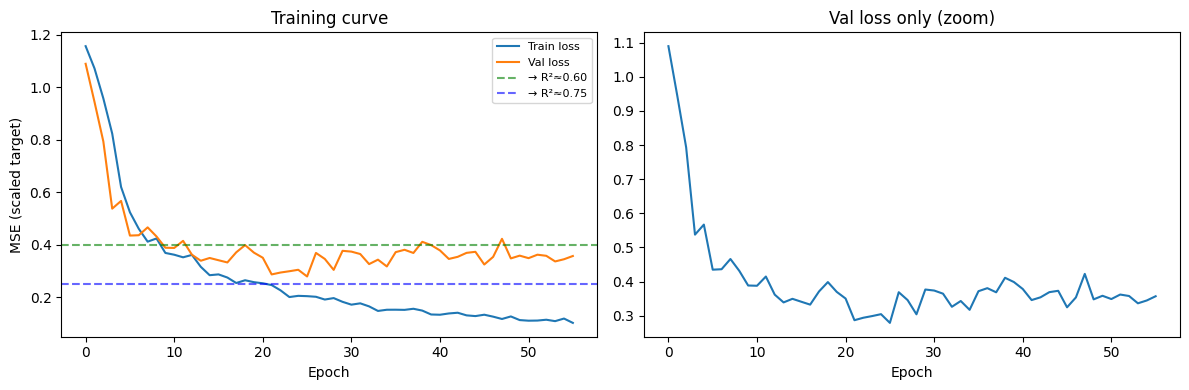

Best val_loss : 0.2790
Expected R²   : ~0.7210

✅ Model learned — run Cell D


In [149]:
import matplotlib.pyplot as plt
import keras
import numpy as np

class WarmupCosineDecay(keras.callbacks.Callback):
    def __init__(self, lr_start=1e-5, lr_peak=5e-4, lr_min=1e-6,
                 warmup_epochs=15, total_epochs=300):
        super().__init__()
        self.lr_start      = lr_start
        self.lr_peak       = lr_peak
        self.lr_min        = lr_min
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.lr_start + (self.lr_peak - self.lr_start) * \
                 (epoch / self.warmup_epochs)
        else:
            progress = (epoch - self.warmup_epochs) / \
                       (self.total_epochs - self.warmup_epochs)
            lr = self.lr_min + 0.5 * (self.lr_peak - self.lr_min) * \
                 (1 + np.cos(np.pi * progress))

        # ✅ Keras 3 fix: direct assignment instead of keras.backend.set_value
        self.model.optimizer.learning_rate = float(lr)


callbacks = [
    WarmupCosineDecay(
        lr_start=1e-5,
        lr_peak=5e-4,
        lr_min=1e-6,
        warmup_epochs=15,
        total_epochs=300
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True,
        start_from_epoch=20,
        verbose=1
    )
]

history = model.fit(
    X_train_tf, y_train_tf,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# ── Diagnostic plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].axhline(0.40, color='green', linestyle='--', alpha=0.6, label='→ R²≈0.60')
axes[0].axhline(0.25, color='blue',  linestyle='--', alpha=0.6, label='→ R²≈0.75')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE (scaled target)')
axes[0].set_title('Training curve')
axes[0].legend(fontsize=8)

axes[1].plot(history.history['val_loss'])
axes[1].set_xlabel('Epoch')
axes[1].set_title('Val loss only (zoom)')

plt.tight_layout()
plt.show()

best_val = min(history.history['val_loss'])
print(f"Best val_loss : {best_val:.4f}")
print(f"Expected R²   : ~{1 - best_val:.4f}")
print()
if best_val > 0.50:
    print("⚠️  val_loss still high — check curve:")
    print("   Flat from epoch 1 → run the Residual MLP fallback from previous message")
    print("   Decreasing but slow → model is learning, just needs more epochs")
else:
    print("✅ Model learned — run Cell D")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
FT-Transformer R²  : 0.5962
FT-Transformer RMSE: 394.4965


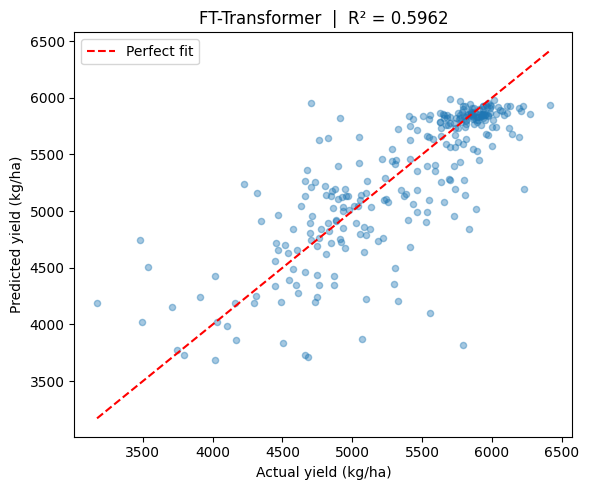

In [150]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Predict on test set
preds_scaled = model.predict(X_test_tf)          # shape (N, 1) — scaled target

# Inverse transform back to original kg/ha scale
tf_preds = scaler_y.inverse_transform(preds_scaled).flatten()

# Evaluate against original (unscaled) y_test
r2_tf   = r2_score(y_test, tf_preds)
rmse_tf = np.sqrt(mean_squared_error(y_test, tf_preds))

print(f"FT-Transformer R²  : {r2_tf:.4f}")
print(f"FT-Transformer RMSE: {rmse_tf:.4f}")

# ── Actual vs Predicted plot ─────────────────────────────────────
plt.figure(figsize=(6, 5))
plt.scatter(y_test, tf_preds, alpha=0.4, s=20)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=1.5, label='Perfect fit')
plt.xlabel('Actual yield (kg/ha)')
plt.ylabel('Predicted yield (kg/ha)')
plt.title(f'FT-Transformer  |  R² = {r2_tf:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

In [151]:
# 🔁 Retrain best_model on FINAL selected features

from sklearn.base import clone

best_model_final = clone(best_model)

best_model_final.fit(X_train_final, y_train)

print("best_model retrained on selected features")

best_model retrained on selected features


In [152]:
ml_preds = best_model_final.predict(X_test_final)

In [153]:
# 🤝 Final Hybrid Ensemble (ML + MLP + TabNet + Transformer) – FIXED

# Weighted average: best ML model gets highest weight
final_preds = (
    0.4 * ml_preds +
    0.3 * mlp_preds +
    0.2 * tabnet_preds +
    0.1 * tf_preds
)

print("Ensemble predictions ready")

Ensemble predictions ready


In [154]:
# 📊 Final Evaluation

r2_final = r2_score(y_test, final_preds)
rmse_final = np.sqrt(mean_squared_error(y_test, final_preds))
mae_final = mean_absolute_error(y_test, final_preds)

print("\n===== FINAL HYBRID ENSEMBLE =====")
print("R2 Score:", r2_final)
print("RMSE:", rmse_final)
print("MAE:", mae_final)


===== FINAL HYBRID ENSEMBLE =====
R2 Score: 0.7986663022694886
RMSE: 278.54970562859774
MAE: 203.13046641418012


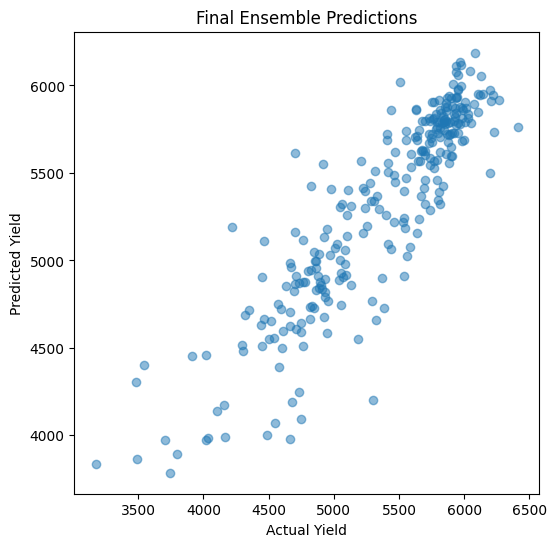

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, final_preds, alpha=0.5)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Final Ensemble Predictions")
plt.show()

In [156]:
# 📊 SHAP Explainability

!pip install shap --quiet

In [157]:
import shap

# Use final trained model
explainer = shap.Explainer(best_model_final, X_train_final)

shap_values = explainer(X_test_final)

 95%|=================== | 262/277 [00:11<00:00]       

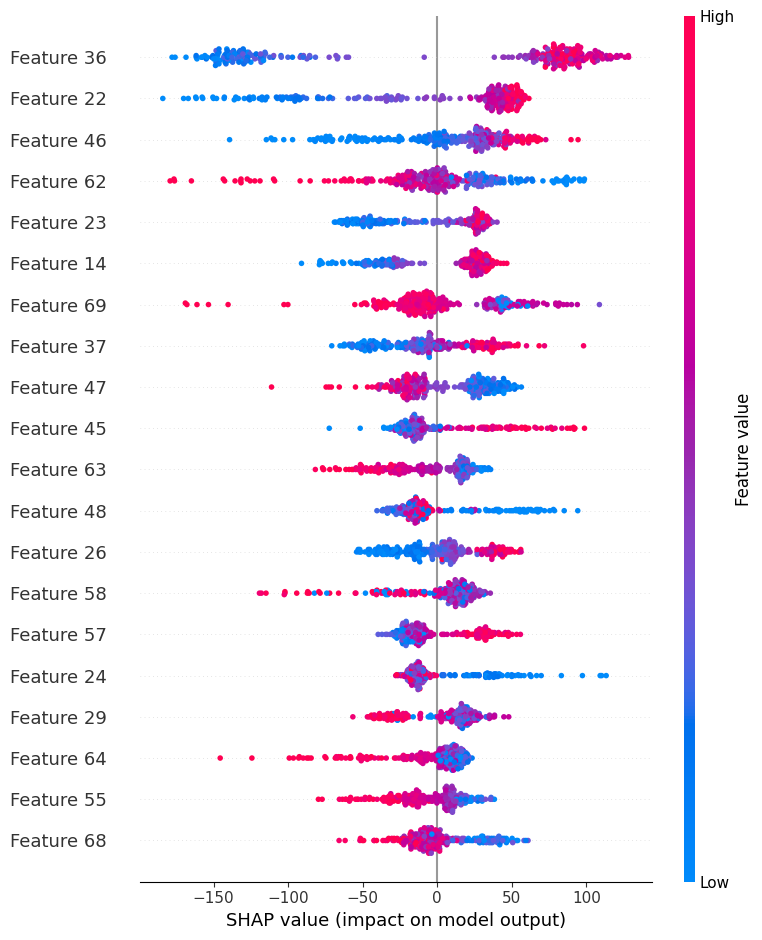

In [158]:
# 🔥 Global feature importance

shap.summary_plot(shap_values, X_test_final)

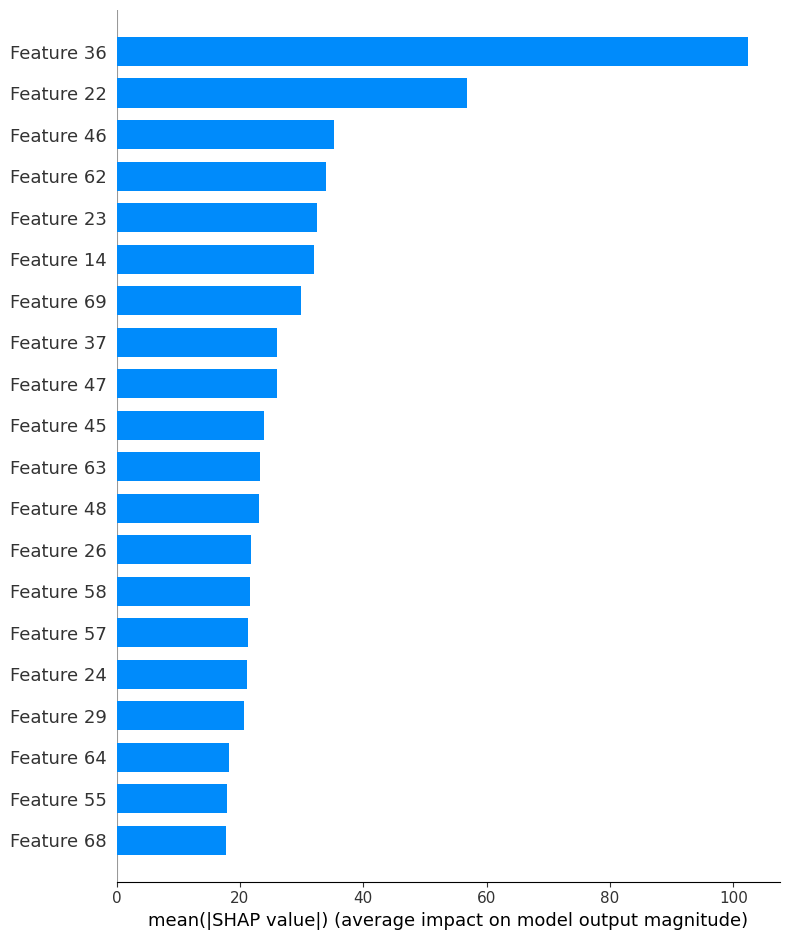

In [159]:
shap.summary_plot(shap_values, X_test_final, plot_type="bar")

In [160]:
!pip install lime --quiet

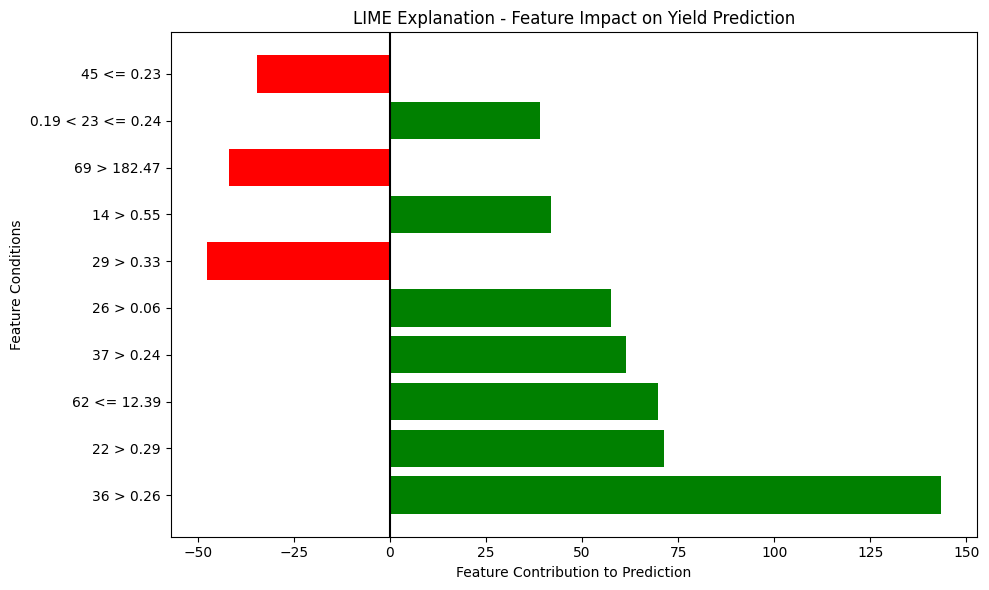

In [174]:
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import numpy as np

explainer_lime = LimeTabularExplainer(
    X_train_final,
    mode='regression'
)

exp = explainer_lime.explain_instance(
    X_test_final[0],
    best_model_final.predict
)

# Get explanation
vals = exp.as_list()
features = [v[0] for v in vals]
importance = [v[1] for v in vals]

colors = ['green' if v > 0 else 'red' for v in importance]

plt.figure(figsize=(10,6))
plt.barh(features, importance, color=colors)
plt.xlabel("Feature Contribution to Prediction")
plt.ylabel("Feature Conditions")
plt.title("LIME Explanation - Feature Impact on Yield Prediction")

plt.axvline(0, color='black')
plt.tight_layout()
plt.show()

In [175]:
pred = best_model_final.predict(X_test_final[0].reshape(1,-1))[0]

print("Predicted Yield:", pred)

Predicted Yield: 5735.74957471615


In [162]:
!pip install anchor-exp --quiet

In [163]:
# ==============================
# ANCHOR EXPLANATIONS (FIXED)
# ==============================

!pip install anchor-exp --quiet

from anchor import anchor_tabular
import numpy as np
import pandas as pd

# Convert regression → classification using bins
y_bins = pd.qcut(y_train, q=3, labels=False)

def predict_fn(X):
    preds = best_model_final.predict(X)
    return pd.qcut(preds, q=3, labels=False)

feature_names = list(X_train_final.columns)

explainer = anchor_tabular.AnchorTabularExplainer(
    class_names=["low", "medium", "high"],
    feature_names=feature_names,
    train_data=X_train_final.values
)

idx = 0

exp = explainer.explain_instance(
    X_test_final.values[idx],
    predict_fn,
    threshold=0.95
)

print("Anchor rule:")
print(" AND ".join(exp.names()))

Anchor rule:
0.96 < feature_83 <= 1.13 AND 0.19 < feature_21 <= 0.22 AND feature_67 <= 9.62 AND 0.26 < feature_40 <= 0.30 AND 0.40 < feature_13 <= 0.44 AND 0.58 < feature_5 <= 0.63 AND 0.36 < feature_1 <= 0.41 AND feature_35 > 0.11 AND 23.89 < feature_50 <= 32.75 AND 0.25 < feature_12 <= 0.29 AND feature_71 <= 98.53 AND 0.19 < feature_23 <= 0.24 AND 0.07 < feature_18 <= 0.10 AND feature_6 > 0.73 AND feature_33 > 0.02 AND -0.36 < feature_64 <= 1.14 AND feature_70 <= 112.59 AND 14.34 < feature_55 <= 15.52 AND feature_0 > 0.51 AND feature_75 <= 201.73 AND 6.70 < feature_58 <= 8.17 AND feature_81 <= 0.22 AND 5.51 < feature_66 <= 6.60 AND feature_62 <= 12.39 AND 0.64 < feature_77 <= 0.70 AND feature_30 > 0.33 AND feature_60 <= 19.41 AND 24.54 < feature_61 <= 25.45 AND 11.19 < feature_46 <= 24.84 AND feature_8 > 0.31 AND feature_79 <= 0.27 AND feature_26 > 0.06 AND feature_43 <= 0.20 AND feature_22 > 0.29 AND feature_24 > 0.08 AND feature_48 > 46.72 AND 0.03 < feature_32 <= 0.04 AND 0.39 < f

In [168]:
import dice_ml
import pandas as pd

# convert to dataframe
data = pd.DataFrame(X_train_final)

# add target
data["yield"] = y_train.values

# dice data
d = dice_ml.Data(
    dataframe=data,
    continuous_features=list(data.columns[:-1]),  # FIXED
    outcome_name="yield"
)

# model
m = dice_ml.Model(
    model=best_model_final,
    backend="sklearn",
    model_type="regressor"
)

# explainer
exp = dice_ml.Dice(d, m)

# query instance
query = pd.DataFrame(X_test_final[0].reshape(1, -1))

dice_exp = exp.generate_counterfactuals(
    query,
    total_CFs=3,
    desired_range=[y.min(), y.max()]
)

dice_exp.visualize_as_dataframe()

100%|██████████| 1/1 [00:02<00:00,  2.28s/it]

Query instance (original outcome : 5736.0)


,0,1,2,3,4,5,6,7,8,9,...,75,76,77,78,79,80,81,82,83,yield
0,0.53353,0.363348,0.420611,0.390685,0.441558,0.593539,0.753398,0.635535,0.340438,0.220344,...,189.617142,240.87886,0.673143,0.278057,0.264171,0.2068,0.220857,0.492,1.0788,5736.0



Diverse Counterfactual set (new outcome: [3111.0, 6889.0])


,0,1,2,3,4,5,6,7,8,9,...,75,76,77,78,79,80,81,82,83,yield
0,0.575026,0.363348,0.420611,0.390685,0.441558,0.593538,0.753398,0.635535,0.340438,0.220344,...,189.617143,240.878857,0.673143,0.278057,0.264171,0.2068,0.220857,0.492,1.0788,5909.233887
1,0.533530,0.363348,0.420611,0.390685,0.441558,0.593538,0.753398,0.635535,0.340438,0.220344,...,189.617143,240.878857,0.673143,0.278057,0.264171,0.2068,0.220857,0.492,1.0788,5735.766113
2,0.533530,0.363348,0.420611,0.390685,0.441558,0.593538,0.753398,0.635535,0.340438,0.220344,...,189.617143,240.878857,0.673143,0.278057,0.264171,0.2068,0.220857,0.492,1.0788,5720.158203


In [169]:
# 📊 Final Comparison Table

comparison_final = pd.DataFrame({
    "Model": [
        "Best ML Model",
        "MLP",
        "Transformer",
        "TabNet",
        "Final Ensemble"
    ],
    "R2 Score": [
        r2_score(y_test, best_model_final.predict(X_test_final)),
        r2_mlp,
        r2_tf,
        r2_tabnet,
        r2_final
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, best_model_final.predict(X_test_final))),
        rmse_mlp,
        rmse_tf,
        rmse_tabnet,
        rmse_final
    ]
})

comparison_final

,Model,R2 Score,RMSE
0,Best ML Model,0.795734,280.570737
1,MLP,0.734076,320.127884
2,Transformer,0.596171,394.496480
3,TabNet,0.661316,361.278469
4,Final Ensemble,0.798666,278.549706


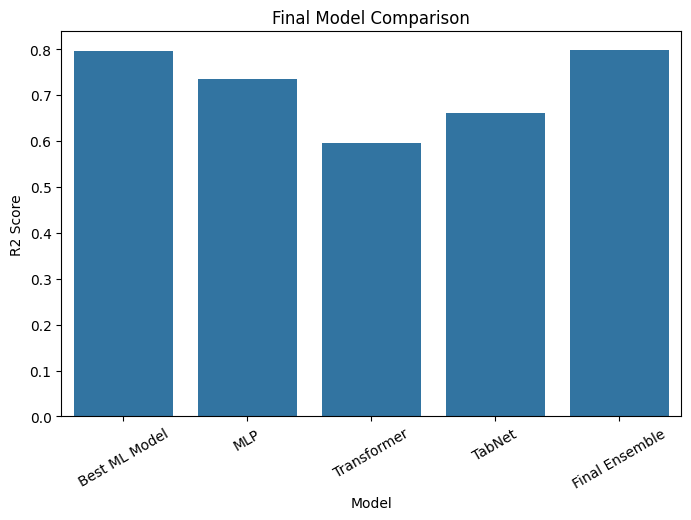

In [170]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="R2 Score", data=comparison_final)
plt.xticks(rotation=30)
plt.title("Final Model Comparison")
plt.show()

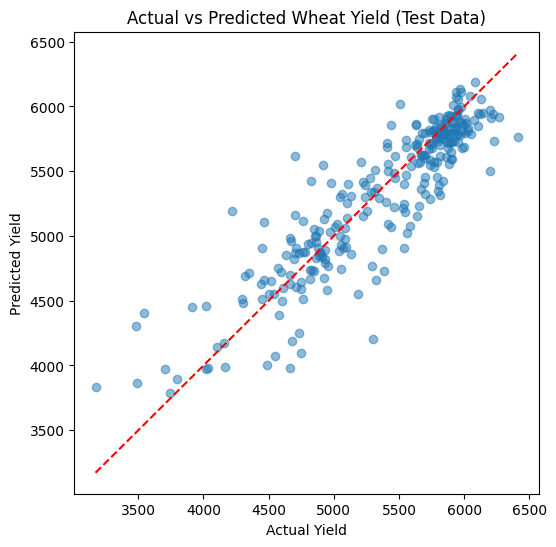

In [171]:
# 📊 Actual vs Predicted (Final Model)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, final_preds, alpha=0.5)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Wheat Yield (Test Data)")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.show()

In [172]:
# 📊 Train vs Test Performance

# Train predictions
train_preds = best_model_final.predict(X_train_final)

# Train metrics
r2_train = r2_score(y_train, train_preds)
rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))

# Test metrics (already have final_preds)
print("===== TRAIN vs TEST =====")
print("Train R2:", r2_train)
print("Test R2:", r2_final)

print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_final)

===== TRAIN vs TEST =====
Train R2: 0.9769361851234614
Test R2: 0.7986663022694886
Train RMSE: 97.70600786689026
Test RMSE: 278.54970562859774
